<Figure size 640x480 with 0 Axes>

cuda:0
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


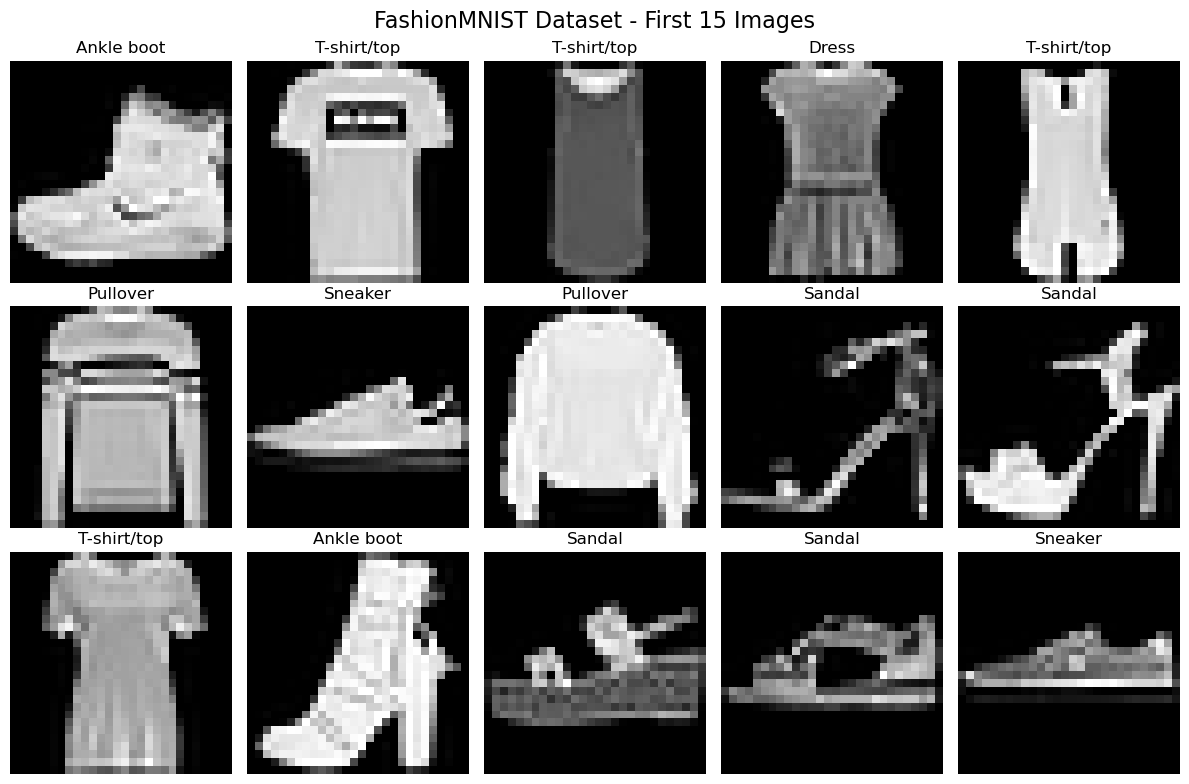

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

plt.tight_layout()
plt.show()

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)



transform = transforms.Compose([transforms.ToTensor(),])

train_dataset = datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = datasets.FashionMNIST(root='./data',train=False,download=True,transform=transform)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
fig.suptitle('FashionMNIST Dataset - First 15 Images', fontsize=16)

for i in range(15):

    image, label = train_dataset[i]
    image_np = image.squeeze().numpy()
    axes[i // 5, i % 5].imshow(image_np, cmap='gray')
    axes[i // 5, i % 5].set_title(f'{class_names[label]}')
    axes[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.show()

In [2]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=4)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=4)

In [3]:
#模型搭建

import torch
import torch.nn as nn

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0,bias = True):
        super(SeparableConv2d, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size = kernel_size, stride=stride, padding=padding, groups=in_channels,bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1,stride=1, padding=0, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class CNN(nn.Module):
    def __init__(self,activation=nn.ReLU,**act_kwargs):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.relu = activation(**act_kwargs)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)
        
        x = self.relu(self.conv5(x))
        x = self.relu(self.conv6(x))
        x=self.pool(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN(activation=nn.SELU)

dummy_input = torch.randn(32, 1, 28, 28)
output = model(dummy_input)
print(output.shape)

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(name,":",num_params)

print(f"Total number of parameters: {total_params}")

torch.Size([32, 10])
conv1.weight : 288
conv1.bias : 32
conv2.weight : 9216
conv2.bias : 32
conv3.weight : 18432
conv3.bias : 64
conv4.weight : 36864
conv4.bias : 64
conv5.weight : 73728
conv5.bias : 128
conv6.weight : 147456
conv6.bias : 128
fc1.weight : 147456
fc1.bias : 128
fc2.weight : 1280
fc2.bias : 10
Total number of parameters: 435306


In [6]:
#training the model

import torch.nn as nn
import torch.optim as optim
import my_trainer as mt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


trainer = mt.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500
)

trainer.train(10)

 

[Step 500] Val Loss: 0.3897 Val Acc: 0.8567
[Step 1000] Val Loss: 0.3418 Val Acc: 0.8739
[Step 1500] Val Loss: 0.3258 Val Acc: 0.8762
Epoch [1/10]  Train Loss: 0.4185  Train Acc: 0.8450
[Step 2000] Val Loss: 0.3636 Val Acc: 0.8768
[Step 2500] Val Loss: 0.3275 Val Acc: 0.8837
[Step 3000] Val Loss: 0.3840 Val Acc: 0.8677
[Step 3500] Val Loss: 0.3005 Val Acc: 0.8927
Epoch [2/10]  Train Loss: 0.3052  Train Acc: 0.8876
[Step 4000] Val Loss: 0.2882 Val Acc: 0.9004
[Step 4500] Val Loss: 0.3694 Val Acc: 0.8717
[Step 5000] Val Loss: 0.2892 Val Acc: 0.8985
[Step 5500] Val Loss: 0.2932 Val Acc: 0.8995
Epoch [3/10]  Train Loss: 0.2660  Train Acc: 0.9041
[Step 6000] Val Loss: 0.3082 Val Acc: 0.8961
[Step 6500] Val Loss: 0.3088 Val Acc: 0.8997
[Step 7000] Val Loss: 0.2828 Val Acc: 0.8980
[Step 7500] Val Loss: 0.3002 Val Acc: 0.9020
Epoch [4/10]  Train Loss: 0.2510  Train Acc: 0.9089
[Step 8000] Val Loss: 0.2859 Val Acc: 0.9021
[Step 8500] Val Loss: 0.2916 Val Acc: 0.8987
[Step 9000] Val Loss: 0.2837

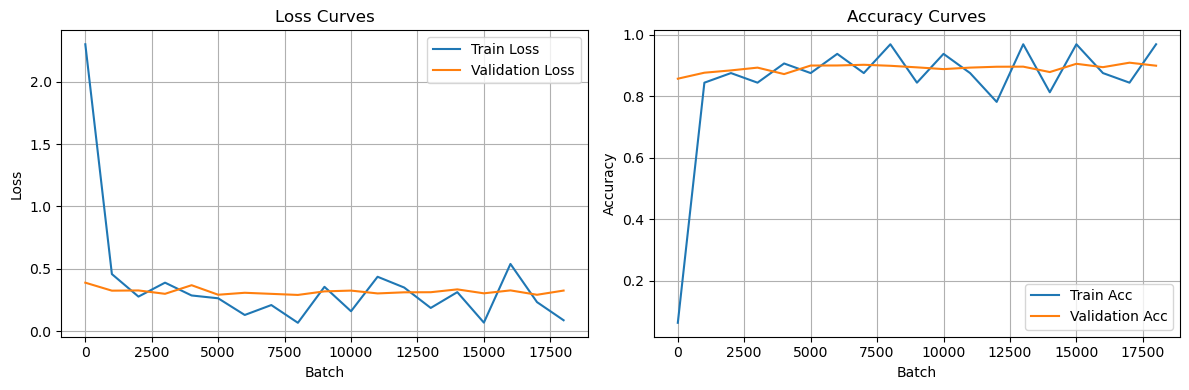

In [7]:
trainer.plot_curves()